# Test EMRI sources|

In [1]:
import os
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np
from few.utils.constants import YRSID_SI
from emrisearch.jax_utils import psd, det_stat
from emrisearch.search_utils import generate_emri_signal_and_sfts
from tqdm import trange
from emrisearch.search_utils import det_stat as det_stat_evolution

/opt/miniconda3/envs/emri/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


Using TDI PSD
Using TDI PSD


## Step 1: Set Parameters

Define the EMRI parameters and search settings. To reduce computational cost, we search for a single plunge time (`Tpl`) and use a smaller batch size.

In [2]:
# EMRI and search parameters
m1 = 4e6  # Primary mass (solar masses)
m2 = 10.0  # Secondary mass (solar masses)
a = 0.0  # Spin parameter
Tpl = 0.9  # Plunge time (years)
ef = 0.0  # Final eccentricity
T_sft = 86400 * 2.  # SFT duration (seconds)
T_data = 1.0  # Total data duration (years)
deltaT = 5.0  # Time step (seconds)
snr_ref = 30.0  # Reference SNR
T_snr = 1.0  # SNR duration (years)
output_dir = './test/'  # Output directory
os.makedirs(output_dir, exist_ok=True)
np.random.seed(2601)

## Step 2: Generate EMRI Signal and SFTs

Generate the simulated EMRI signal and Short Fourier Transforms (SFTs) using the provided utility function.

In [3]:
true_values = np.array([m1, m2, a, Tpl, ef, 1.0])
injection_dict = generate_emri_signal_and_sfts(true_values, T_data, T_sft, deltaT, snr_ref, T_snr)
t_alpha = injection_dict['t_alpha']
phi, f_phi_r, dotf, dotdotf = injection_dict['true_phi_f_fdot_fddot']
samples_per_sft = injection_dict['samples_per_sft']
data_sfts = jnp.asarray(injection_dict['data_sfts'], dtype=jnp.complex128)
noise_sfts = jnp.asarray(injection_dict['noise_sfts'], dtype=jnp.complex128)
signal_sfts = jnp.asarray(injection_dict['signal_sfts'], dtype=jnp.complex128)

Using response generator
Waveform generated on CPU
Final SNR: 29.999999999999996


## Step 3: Plot True Frequency Track

Visualize the true frequency track in the SFT data for the harmonic (m=2, n=0).

Log-likelihood ratio (m,n)=(2,0): -665.5053270029406
Log-likelihood ratio (m,n)=(3,0): -514.648977531853
Log-likelihood ratio (m,n)=(4,0): -411.75108429935926
Log-likelihood ratio (m,n)=(5,0): -318.2480407729618


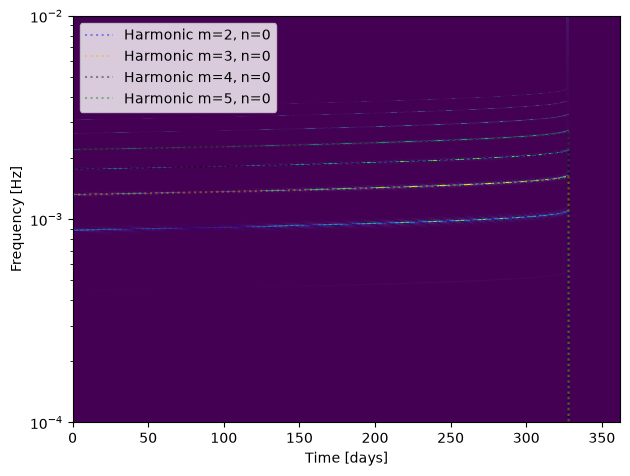

In [4]:
frequencies = np.fft.rfftfreq(samples_per_sft, deltaT)
plt.figure()
plt.imshow(np.abs(injection_dict['signal_sfts']),aspect='auto',origin='lower',extent=[0, t_alpha[-1]/86400, frequencies[0], frequencies[-1]],cmap='viridis')
plt.ylim(1e-4, 0.015)
for m,n,col in [(2,0,"blue"), (3,0,"orange"), (4,0,"black"), (5,0,"green")]:
    f_alpha = jnp.asarray(m*f_phi_r[0] + n*f_phi_r[1], dtype=jnp.float64)
    fdot_alpha = jnp.asarray(m*dotf[0] + n*dotf[1], dtype=jnp.float64)
    ll_d = det_stat(injection_dict['data_sfts'], f_alpha, fdot_alpha, T_sft=T_sft)
    ll_h = det_stat(injection_dict['signal_sfts'], f_alpha, fdot_alpha, T_sft=T_sft)
    ll_n = det_stat(injection_dict['noise_sfts'], f_alpha, fdot_alpha, T_sft=T_sft)
    ll_new = det_stat(injection_dict['new_noise_sfts'], f_alpha, fdot_alpha, T_sft=T_sft)
    nll_true =  - ll_d
    print(f"Log-likelihood ratio (m,n)=({m},{n}): {nll_true}")
    plt.plot(t_alpha/86400, f_alpha, ':', label=f'Harmonic m={m}, n={n}', alpha=0.4, color=col)

plt.semilogy()
plt.legend(loc='upper left')
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.tight_layout()
plt.ylim(1e-4, 0.01)
plt.savefig(output_dir + '/true_frequency_track.png', dpi=300)

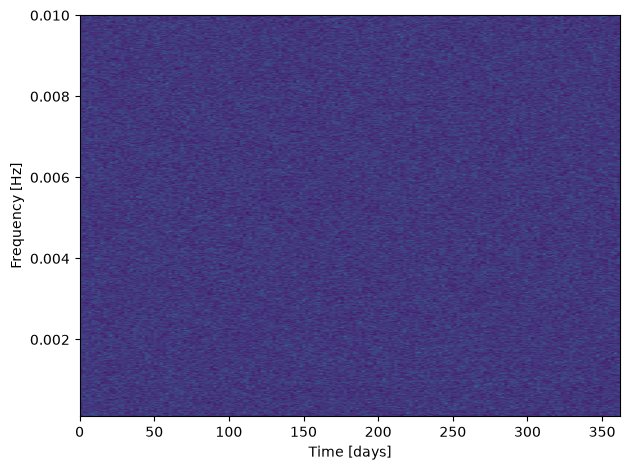

In [5]:
toplot = np.array(data_sfts) / np.array(psd(frequencies))[:,None]**0.5

plt.figure()
plt.imshow(np.abs(toplot), aspect='auto', origin='lower',
           extent=[0, t_alpha[-1]/86400, frequencies[0], frequencies[-1]], cmap='viridis')
plt.ylim(1e-4, 0.01)
plt.xlabel('Time [days]')
plt.ylabel('Frequency [Hz]')
plt.tight_layout()
plt.savefig(output_dir + '/injected_data_sft.png', dpi=300)
plt.show()

In [13]:
fdot_alpha = np.gradient(f_alpha, t_alpha)
fddot_alpha = np.gradient(fdot_alpha, t_alpha)
delta_phi_approx = np.abs(fddot_alpha * T_sft**3 / 6)
A_alpha = np.where((f_alpha > 10**(-3.5)) & (fdot_alpha > 1e-13) & (delta_phi_approx < 1.0), 1.0, 0.0)
phi_alpha = np.ones_like(f_alpha)

mfilter_hh = injection_dict['m_hh']
mfilter_dh = np.abs(injection_dict['m_hd'])**2/(mfilter_hh)

S_sig_dict = {}
S_data_dict = {}
for m,n,col in [(2,0,"blue"), (3,0,"orange"), (4,0,"black"), (5,0,"green")]:
    f_alpha = jnp.asarray(m*f_phi_r[0] + n*f_phi_r[1], dtype=jnp.float64)
    fdot_alpha = jnp.asarray(m*dotf[0] + n*dotf[1], dtype=jnp.float64)
    dh, hh = det_stat_evolution(np.asarray(data_sfts), A_alpha, phi_alpha, f_alpha, fdot_alpha, T_sft=T_sft)
    S_data = np.abs(dh)**2 / hh
    S_data_dict[(m,n)] = S_data
    
    dh, hh = det_stat_evolution(np.asarray(signal_sfts), A_alpha, phi_alpha, f_alpha, fdot_alpha, T_sft=T_sft)
    S_signal = np.abs(dh)**2 / hh
    S_sig_dict[(m,n)] = S_signal


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_56767/1392904840.py:8: RuntimeWarning: invalid value encountered in divide
  mfilter_dh = np.abs(injection_dict['m_hd'])**2/(mfilter_hh)
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_56767/1392904840.py:16: RuntimeWarning: invalid value encountered in divide
  S_data = np.abs(dh)**2 / hh
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_56767/1392904840.py:20: RuntimeWarning: invalid value encountered in divide
  S_signal = np.abs(dh)**2 / hh


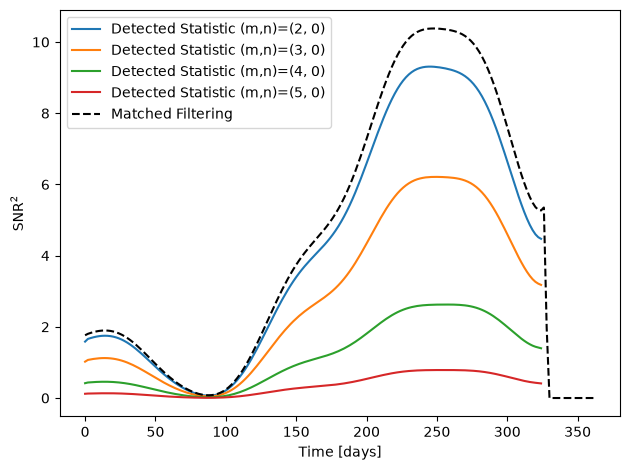

In [16]:
plt.figure()
for key in S_sig_dict.keys():
    S_signal = S_sig_dict[key]
    S_data = S_data_dict[key]
    plt.plot(t_alpha/86400, S_signal, label=f'Detected Statistic (m,n)={key}')
plt.plot(t_alpha/86400, mfilter_hh, label='Matched Filtering', color='k', linestyle='--')
plt.xlabel('Time [days]')
plt.ylabel('SNR$^2$')
plt.legend()
plt.tight_layout()


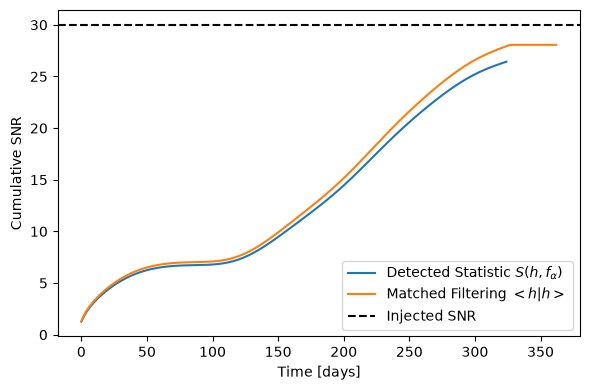

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(t_alpha/86400, np.cumsum(S_sig_dict[(2,0)])**0.5, label='Detected Statistic $S(h,f_\\alpha)$')
plt.plot(t_alpha/86400, np.cumsum(mfilter_hh)**0.5, label='Matched Filtering $<h|h>$')
plt.axhline(snr_ref, color='k', linestyle='--', label='Injected SNR')
plt.xlabel('Time [days]')
plt.ylabel('Cumulative SNR')
plt.legend()
plt.tight_layout()
plt.savefig(output_dir + '/det_stat_evolution.png', dpi=300)
